Parameters Optimization (Work in Progress)

I integrated BluePyOpt and eFEL to fine-tune the maximum conductances (gNa, gKDR, gM, gKCa, gCa) against experimental I/f curves.
The current implementation in the notebook runs with a minimal population size (offspring_size=3) and few generations (max_ngen=3) purely for local testing, benchmarking, and code validation.
To achieve full convergence and replicate the experimental plateau (around 350 pA), the script is ready to be scaled up on a High-Performance Computing (HPC) cluster with a larger population (e.g., 50+ individuals, 50+ generations) to fully explore the multi-objective Pareto front.

In [1]:
# Required libreries

import numpy as np
import matplotlib.pyplot as plt
import neuron
from neuron import h
import bluepyopt as bpo
import bluepyopt.deapext.optimisations as optimisations
import efel


In [2]:
# Model morphology

As = 0.015 # As: soma area in mm2
Ad = 0.035 # Ad: dendrite area in mm2

soma = h.Section(name='soma')
soma.L    = 70  # Soma length in μm
soma.diam = 68  # Soma diameter in μm
soma.nseg = 1   # Number of segments of the soma
soma.cm   = 1   # Membrane capacitance in μF/cm2     

dend = h.Section(name='dend')
dend.L     = 680  # Dendrite length in μm
dend.diam  = 17   # Dendrite diameter in μm
dend.nseg  = 1    # Number of segments of the dendrite
dend.cm    = 1    # Membrane capacitance in μF/cm2   

# Dendrite sizes chosen to have coupling between soma and dendrite with a conductance of 1.75 μS,
# corrisponding to an axial resistance (dend.ri) of 0.57 MΩ.

h.celsius  = 30   # Temperature in Celsius degrees
dend.connect(soma(1),0);  # To connect the top of the dendrite to the bottom of the soma


In [3]:
# -------------------------------------------------------------------------------------------------------------------------------
# Model mechanisms
# -------------------------------------------------------------------------------------------------------------------------------

# In the soma
soma.insert('KNa') 
soma.insert('KDR') 
soma.insert('Na') 
soma.insert('KS')
soma.insert('KA')
soma.insert('leak')

# In the dendrite
dend.insert('NaP') 
dend.insert('KAR')
dend.insert('KCa')
dend.insert('Ca')
dend.insert('leak') 

# Mechanisms added by Dalla Porta
dend.insert('Ih') 
soma.insert('IM'); 

# Modifing mechanisms parameters
soma.gL_leak = 0.0667e-3*0.3 
dend.gL_leak = 0.0667e-3*0.3 


In [4]:
# ------------------------------------------------------------------------------------------------------------------------------
# Current/frequency relationship before parameters optimization
# ------------------------------------------------------------------------------------------------------------------------------

I = np.arange(0,0.61,0.025)
freq = np.zeros(len(I))

h.load_file('stdrun.hoc')
# The following 3 lines are required for adaptive integration (to make the code faster)
Hines = h.CVode() 
Hines.active(1) 
Hines.use_local_dt(1)     

iclampS = h.IClamp(soma(0.5))
iclampS.delay = 2000 
iclampS.dur = 1000

for i in range (len(I)):
    
    iclampS.amp = I[i] 

    apc = h.APCount(0.5)
    apc.thresh = -20  

    v = h.Vector().record(soma(0.5)._ref_v)             
    t = h.Vector().record(h._ref_t) 

    h.finitialize(-65)
    h.tstop = 4000
    h.run()                         
    freq[i] = 1000*apc.n/(iclampS.dur)  


Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt


In [5]:
# ------------------------------------------------------------------------------------------------------------------------------
# Parameters optimization with BluePyOpt
# ------------------------------------------------------------------------------------------------------------------------------


# Define the Evaluator class inheriting from bpo.evaluators.Evaluator.
# This object acts as a bridge between the Distributed Evolutionary Algorithms in Python (DEAP) and the simulator (NEURON).
class PyramidalCellEvaluator(bpo.evaluators.Evaluator):
    def __init__(self, target_if_data):
        # Call the base class constructor to register the evaluator instance
        super(PyramidalCellEvaluator, self).__init__()
        
        # Target current steps (in nA) to inject for testing the cell at each evaluation
        self.target_currents = np.arange(0,0.61,0.025)
        # Save the experimental (target) firing frequencies corresponding to each step
        self.target_frequencies = target_if_data['freq'] 
        
        # Define the free parameters that the genetic algorithm will optimize.
        # Assign a string label and the minimum and maximum boundaries (bounds) to each parameter.
        self.params = [
            bpo.parameters.Parameter('soma_gNa', bounds=[5e-3, 500e-3]),   # Spike generation
            bpo.parameters.Parameter('soma_gKDR', bounds=[1e-3, 100e-3]),  # Fast repolarization
            bpo.parameters.Parameter('soma_gM', bounds=[0.0, 1e-3]),       # Voltage-dependent brake (Plateau)
            bpo.parameters.Parameter('dend_gKCa', bounds=[0.0, 5e-3]),     # Calcium-dependent brake (Adaptation)
            bpo.parameters.Parameter('dend_gCa', bounds=[0.0, 4e-3])]       # Ca++ source for the KCa channel
        
        # Define an error objective (Objective) for each defined current step.
        # BluePyOpt will treat the problem as a multi-objective optimization.
        self.objectives = [bpo.objectives.Objective(f'step_{i}_freq_score') for i in range(len(self.target_currents))]

    # Direct interface required by DEAP to convert raw parameter lists
    # (the float vectors generated by genetic cross-overs and mutations) into physical evaluations
    def init_simulator_and_evaluate_with_lists(self, param_list):
        # Create a dictionary by associating each parameter name with the current proposed float value
        param_dict = {p.name: val for p, val in zip(self.params, param_list)}
        
        # Dynamically apply current values to NEURON's global conductance variables
        soma.gNa_Na = param_dict['soma_gNa']
        soma.gK_KDR = param_dict['soma_gKDR']
        soma.gM_IM = param_dict['soma_gM']
        dend.gKCa_KCa = param_dict['dend_gKCa']
        dend.gCa_Ca = param_dict['dend_gCa']
        
        # Temporary list to collect error scores across the current stimuli
        scores = []
        
        # Loop through each planned electrical stimulus to calculate the cell response
        for i, amp in enumerate(self.target_currents):   

            iclampS.amp = amp  
            
            # Prepare native NEURON vectors to record voltage and time profiles
            v_vec = h.Vector().record(soma(0.5)._ref_v)
            t_vec = h.Vector().record(h._ref_t)
            
            h.finitialize(-65)
            h.tstop = 4000 
            h.run()        
            
            # Structure the extracted vectors into the standard dictionary format ("trace") expected by eFEL
            trace = {
                'T': np.array(t_vec), # NumPy array of sampling times
                'V': np.array(v_vec), # NumPy array of recorded membrane potentials
                'stim_start': [iclampS.delay], # Start of the stimulation interval
                'stim_end': [iclampS.delay + iclampS.dur] # End of the stimulation interval
            }
            
            # Call eFEL functions to extract the value of the 'mean_frequency' feature
            # (The eFEL module will detect threshold crossings and extract the mean frequency during the stimulus)
            features = efel.efel.api.get_mean_feature_values([trace], ['mean_frequency'], raise_warnings=False)
            
            # Verify that the trace generated spikes and that eFEL calculated the feature
            if features[0] and features[0]['mean_frequency'] is not None:
                freq_val = features[0]['mean_frequency']
                # Safely handle potential type variability returned by eFEL (array vs scalar)
                if hasattr(freq_val, '__len__') and len(freq_val) > 0:
                    model_freq = freq_val[0]
                else:
                    model_freq = freq_val
            else:
                model_freq = 0.0 # If the cell does not reach the firing threshold, the resulting frequency is 0 Hz
            
            # Calculate the mathematical distance (absolute error) relative to the experimental target frequency
            target_freq = self.target_frequencies[i]
            score = abs(model_freq - target_freq)
            # Store the penalty score obtained for this specific step
            scores.append(score)
            
        # DEAP strictly requires a tuple or list as output to handle Pareto optimization
        return tuple(scores)

    # Define also the standard evaluate method for internal consistency within the BluePyOpt architecture
    def evaluate(self, individual):
        # Redirect the call directly to the list-based function defined above
        return self.init_simulator_and_evaluate_with_lists(individual)
    

# Optimization Configuration and Launch
if __name__ == '__main__':
    # Experimental I-F curve data
    experimental_data = {'freq': [0, 1, 2, 6, 11, 15, 19, 21, 24, 26, 28, 28, 28, 29, 31, 31, 30, 29, 28, 28, 26, 25, 23, 22, 20],
                         'errors': [0.0, 0.4, 0.8, 1.8, 2.2, 2.5, 2.6, 2.4, 2.5, 2.7, 2.6, 3.2, 3.5, 2.8, 2.4, 2.6, 2.5, 2.8, 3.1, 2.9, 3.8, 3.9, 4.0, 4.3, 4.5]} 
    
    # Initialize the evaluator passing the dictionary of experimental targets
    evaluator = PyramidalCellEvaluator(experimental_data)
    
    # Configure the DEAP algorithm.
    # We set a small population value (offspring_size=3) to speed up local testing.
    opt = optimisations.DEAPOptimisation(
        evaluator=evaluator,
        offspring_size=3)


    # Start the evolutionary engine limiting total iterations (max_ngen=3) for performance reasons.
    pop, HoF, log, history = opt.run(max_ngen=3) # ngen: no of generations

    # Get the specific best individual extracted at the top of the Hall of Fame (HoF)
    best_ind = HoF[0]
    print("\nBest parameters found:")
    # Loop in parallel through the list of structural parameters and their respective optimized final numerical values
    for param, value in zip(evaluator.params, best_ind):
        print(f"{param.name}: {value*1e3} mS")
        

Optimization starting with BluePyOpt...
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Cha

In [6]:
# ------------------------------------------------------------------------------------------------------------------------------
# Current/frequency relationship with optimized paramters
# ------------------------------------------------------------------------------------------------------------------------------

I = np.arange(0,0.61,0.025)
freq_opt = np.zeros(len(I))

for i in range (len(I)):
    iclampS = h.IClamp(soma(0.5))
    iclampS.delay = 2000 
    iclampS.dur = 1000
    iclampS.amp = I[i] 

    apc = h.APCount(0.5)
    apc.thresh = -20  

    v = h.Vector().record(soma(0.5)._ref_v)             
    t = h.Vector().record(h._ref_t) 

    h.finitialize(-65)
    h.tstop = 4000
    h.run()                         
    freq_opt[i] = 1000*apc.n/(iclampS.dur)  
    

Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt
Changed dt


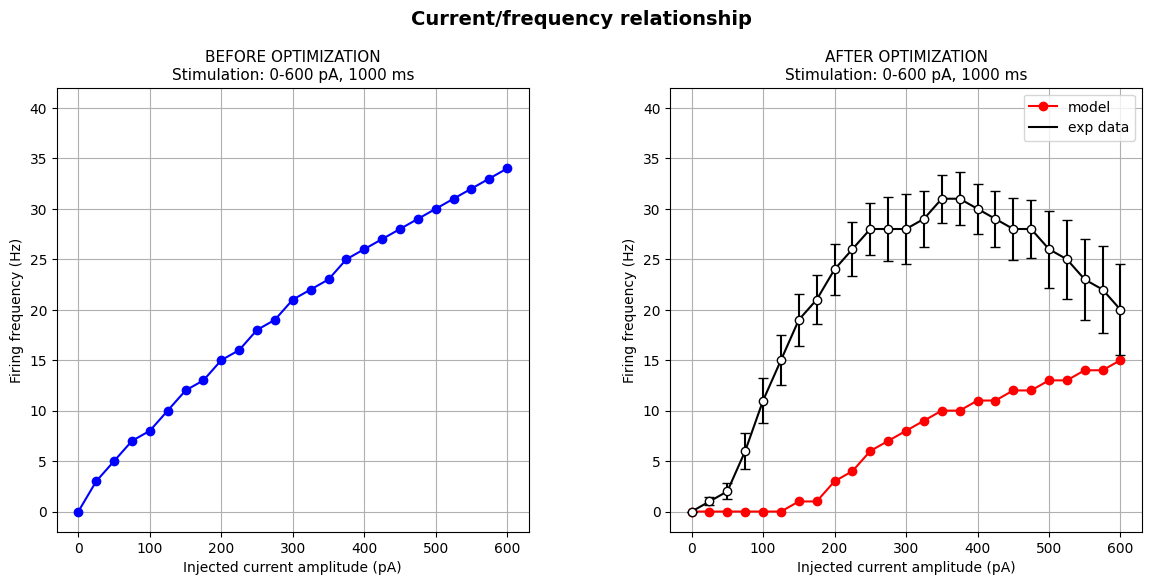

In [10]:
# ------------------------------------------------------------------------------------------------------------------------------
# Results comparison 
# ------------------------------------------------------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- FIRST PLOT (Before optimization) ---
ax1.plot(I * 1000, freq, 'bo-')
ax1.set_xlabel('Injected current amplitude (pA)')
ax1.set_ylabel('Firing frequency (Hz)')
ax1.set_ylim(-2, 42) 
ax1.set_title(f'BEFORE OPTIMIZATION\nStimulation: {int(I[0])}-{int(I[-1]*1e3)} pA, {int(iclampS.dur)} ms', fontsize=11)
ax1.grid()

# --- SECOND PLOT (After optimization) ---
ax2.plot(I * 1000, freq_opt, 'ro-', label='model')
ax2.set_xlabel('Injected current amplitude (pA)')
ax2.set_ylabel('Firing frequency (Hz)')
ax2.set_ylim(-2, 42) 
ax2.set_title(f'AFTER OPTIMIZATION\nStimulation: {int(I[0])}-{int(I[-1]*1e3)} pA, {int(iclampS.dur)} ms', fontsize=11)
ax2.plot(I * 1000, experimental_data['freq'], 'k', label='exp data')
ax2.errorbar(I * 1000, experimental_data['freq'], yerr=experimental_data['errors'], fmt='o', color='black', mfc='white', mec='black', capsize=3.5)
ax2.legend()
ax2.grid()

fig.suptitle(f'Current/frequency relationship', fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.3, top=0.85) # Separating the plots 
plt.show()
